# Conditional NF on Toy Data

Conditional Normalizing Flow on Toy Data.

### Imports

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy.special import logit, expit

import matplotlib.pyplot as plt
import corner

import jax
import jax.numpy as jnp
import optax
import equinox as eqx

# FlowJAX (new API)
from flowjax.flows import masked_autoregressive_flow
from flowjax.distributions import Normal

from pathlib import Path

import seaborn as sns
from tqdm import tqdm, trange

import utils as ut

# silence unnecessary warnings about some specific model not being available (shouldn't hurt performance according to ChatGPT)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import os
import socket
print(f"Hostname: {socket.gethostname()}")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES')}")
!nvidia-smi

Hostname: usm-cl-nv01.hpc.physik.uni-muenchen.de
CUDA_VISIBLE_DEVICES: 0
Wed Jan 28 22:51:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                On  |   00000000:C4:00.0 Off |                    0 |
| N/A   44C    P0             67W /  400W |       0MiB /  95830MiB |      0%      Default |
|                                         |                        

In [3]:
jax.devices()

[CudaDevice(id=0)]

### Generate Data

In [4]:
# let's prepare some fake data: high masses and low redshift -> detected

rng = np.random.default_rng()
m1_detected = rng.normal(loc = 40, scale = 10, size = 50000)
m2_detected = rng.normal(loc = 30, scale = 7.5, size = 50000)
z_detected = rng.normal(loc = 0.3, scale = 0.1, size = 50000)
far_min_detected = rng.uniform(low = 1e-10, high = 1, size = 50000)
m1_not_detected = rng.normal(loc = 10, scale = 6, size = 50000)
m2_not_detected = rng.normal(loc = 6, scale = 2.5, size = 50000)
z_not_detected = rng.normal(loc = 1, scale = 0.2, size = 50000)
far_min_not_detected = rng.uniform(low = 1, high = 100, size = 50000)

detected = np.array([True]*50000 + [False]*50000) # only for selection purpose later, does not show up in training or anywhere else

data_dict = {
    "m1": np.append(m1_detected, m1_not_detected),
    "m2": np.append(m2_detected, m2_not_detected),
    "z": np.append(z_detected, z_not_detected),
    "far_min": np.append(far_min_detected, far_min_not_detected),
    "detected": detected,
}
data_df = pd.DataFrame(data_dict)

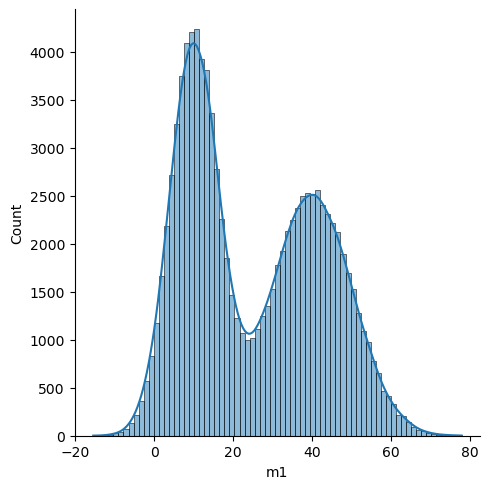

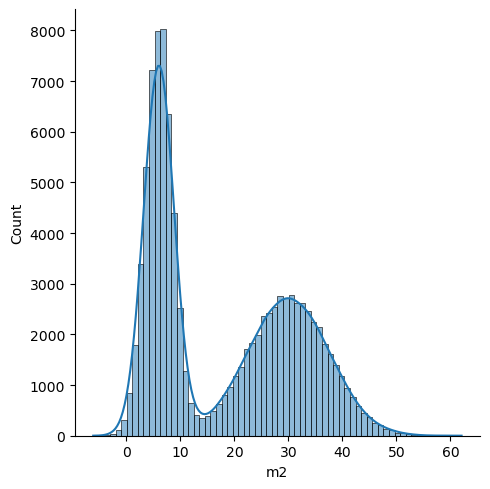

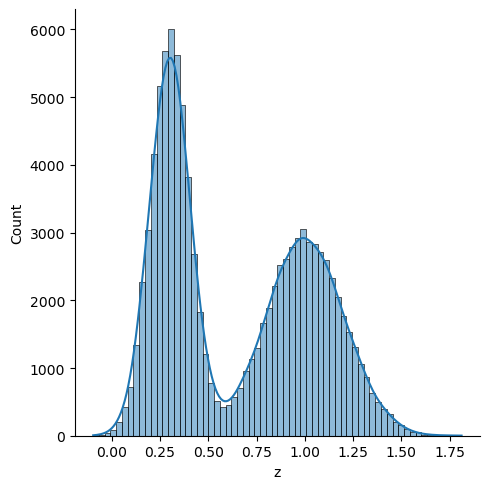

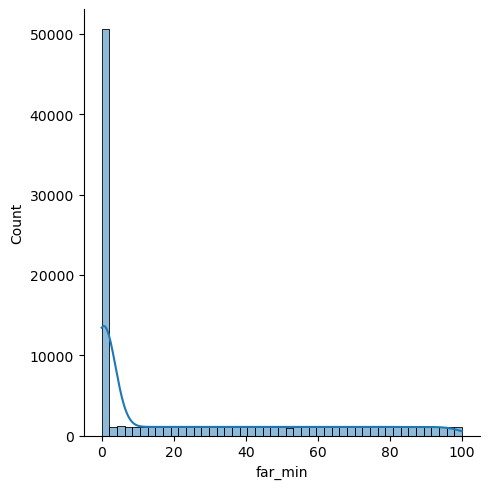

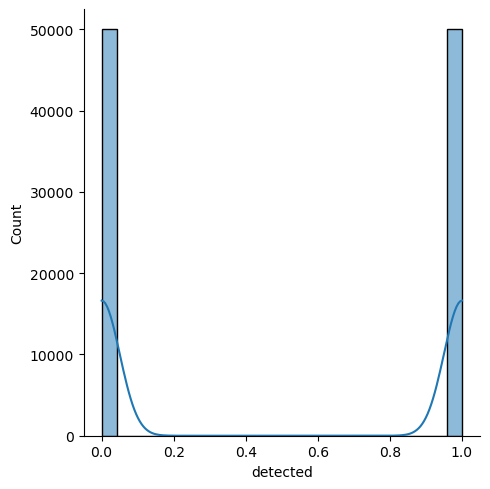

In [5]:
for col in data_df.columns:
    sns.displot(data_df[col], kde = True)
    plt.show()

### Prepare the data

FORWARD / INVERSE TRANSFORMS + WHITENING

In [6]:
conditioning_data = ut.Data(pd.DataFrame(data_df["far_min"]), transforms = ["none"])
X_data = ut.Data(data_df, cols = ["m1", "m2", "z"])
dataset = ut.Dataset(X = X_data, y = conditioning_data, use_whitened_X=True, use_whitened_y = False)

E0128 22:51:20.969123     434 ptx_compiler_helpers.cc:132] *** WARNING *** Invoking ptxas with version 12.6.20, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


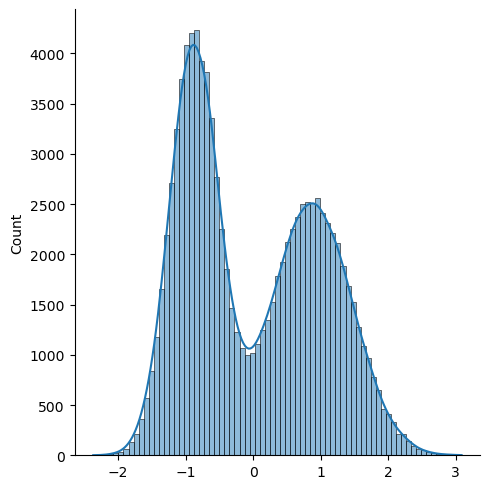

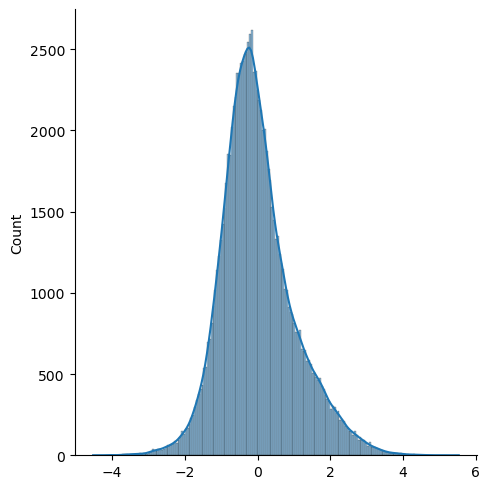

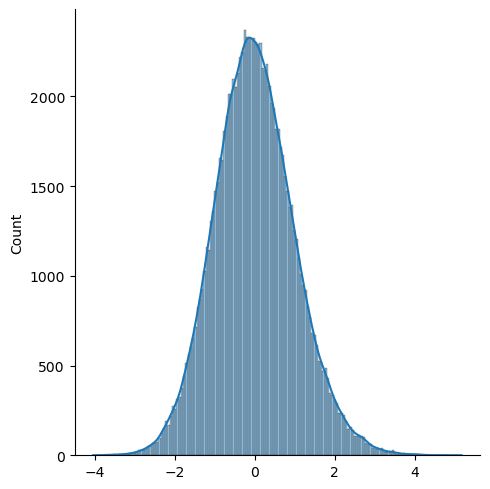

In [7]:
for i in range(dataset.X_data.whitened_data.shape[1]):

    sns.displot(np.array(dataset.X[:, i]), kde=True)
    plt.show()

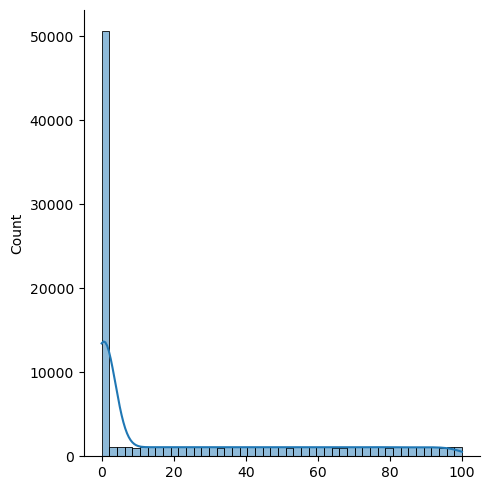

In [8]:
for i in range(dataset.y_data.whitened_data.shape[1]):

    sns.displot(np.array(dataset.y[:, i]), kde=True)
    plt.show()

### Build Flowjax MAF

In [9]:
key = jax.random.key(0)

train_dataset, val_dataset = dataset.split(key, train_frac=0.8)

flow = masked_autoregressive_flow(
    key=key,
    base_dist=Normal(jnp.zeros(train_dataset.X.shape[1])),  # X dimensionality
    cond_dim=train_dataset.y.shape[1],                       # Condition on y
    flow_layers=2,
    nn_width=32,
    nn_depth=4,
)

### Training Loop

In [10]:
# Configuration
batch_size = 4096
n_epochs = 2000
learning_rate = 1e-3

# Create optimizer
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(eqx.filter(flow, eqx.is_array))

# Loss function for conditional flow
@eqx.filter_value_and_grad
def loss_fn(flow, x, condition):
    """Negative log-likelihood for conditional flow."""
    return -jnp.mean(flow.log_prob(x, condition=condition))

# Training step
@eqx.filter_jit
def train_step(flow, opt_state, x, condition):
    """Single training step with gradient update."""
    loss, grads = loss_fn(flow, x, condition)
    updates, opt_state = optimizer.update(grads, opt_state)
    flow = eqx.apply_updates(flow, updates)
    return flow, opt_state, loss

# Training loop
losses = []
N = len(train_dataset)

patience = 250

best_loss = np.inf
best_epoch = 0
best_flow = flow

epochs = trange(1, n_epochs + 1, desc="Training")

for epoch in epochs:
    # Random permutation
    perm = np.random.permutation(N)
    x_perm = train_dataset.X[perm]
    y_perm = train_dataset.y[perm]
    
    batch_losses = []
    for i in range(0, N, batch_size):
        batch_x = x_perm[i:i+batch_size]
        batch_y = y_perm[i:i+batch_size]
        
        # Skip incomplete batches
        if batch_x.shape[0] < batch_size:
            continue
        
        flow, opt_state, loss = train_step(flow, opt_state, batch_x, batch_y)
        batch_losses.append(float(loss))
    
    curr_loss = np.mean(batch_losses)
    losses.append(curr_loss)

    if curr_loss < best_loss:
        best_loss = curr_loss
        best_epoch = epoch
        best_flow = flow

    # Update tqdm bar
    epochs.set_postfix(
        curr=f"{curr_loss:.4f}",
        best=f"{best_loss:.4f}",
    )

    if epoch - best_epoch > patience:
        print(f"Early stopping at epoch {epoch}")
        break


Training:  30%|██▉       | 591/2000 [00:31<01:15, 18.70it/s, best=2.4926, curr=2.4970]

Early stopping at epoch 592


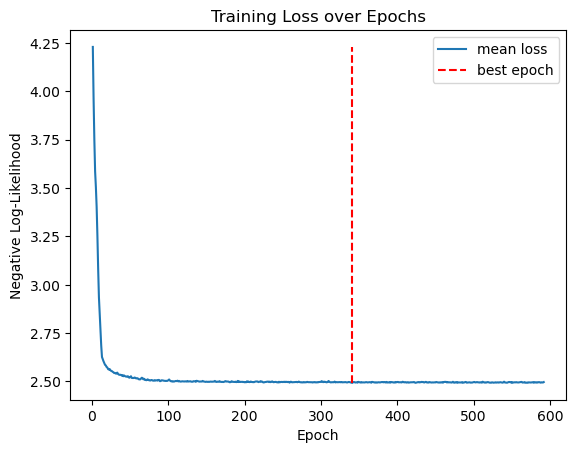

In [11]:
sns.lineplot(x=np.arange(1, len(losses) + 1), y=losses, label = "mean loss")
plt.vlines(x = best_epoch, ymin = min(losses), ymax = max(losses), color = "red", linestyle = "--", label = "best epoch")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Training Loss over Epochs")
plt.show()

In [26]:
data_sel = X_data.full_data_df["detected"] == False

# data_sel = X_data.full_data_df["far_min"] < 50
data_sel &= X_data.full_data_df["far_min"] > 1

# data_sel = np.ones_like(X_data.full_data_df["detected"], dtype = bool)
np.sum(data_sel)

np.int64(50000)

In [27]:
y_orig_batch = jnp.array(np.append(far_min_detected, far_min_not_detected)[data_sel]) # jnp.array(rng.uniform(low = 1, high = 100, size = np.sum(data_sel)))
y_orig_batch = y_orig_batch[:, None]
y_orig_batch.shape, y_orig_batch.min(), y_orig_batch.max()

y0_transformed = dataset.y_data.forward_transform(y_orig_batch)

y0_white, _, _ = dataset.y_data.whiten_data(y_orig_batch)
y0_white.shape, y0_white.min(), y0_white.max(), y0_white.mean()

((50000, 1),
 Array(-1.7230382, dtype=float32),
 Array(1.7356662, dtype=float32),
 Array(1.8127442e-07, dtype=float32))

In [28]:
print("Reminder to check what you did the conditioning data: no transformation, transformation, whitening, transformation + whitening?")

Reminder to check what you did the conditioning data: no transformation, transformation, whitening, transformation + whitening?


In [29]:
cond = y_orig_batch
S = 1
# 4. sample in whitened x-space
z_key, key = jax.random.split(key)
x_white_samples = flow.sample(z_key, (S,), condition=cond)  # (S, dx)

print(x_white_samples.shape, cond.shape)
x_mean_samples = x_white_samples.mean(axis = 0) # dont even need to do this, because the output now is only 1d per generation anyway
print(x_mean_samples.shape)

# 5. map samples back to original x-space
x_samples_orig_space = dataset.to_original_space_X(x_mean_samples)

(1, 50000, 3) (50000, 1)
(50000, 3)


In [30]:
x_samples_orig_space.shape

(50000, 3)

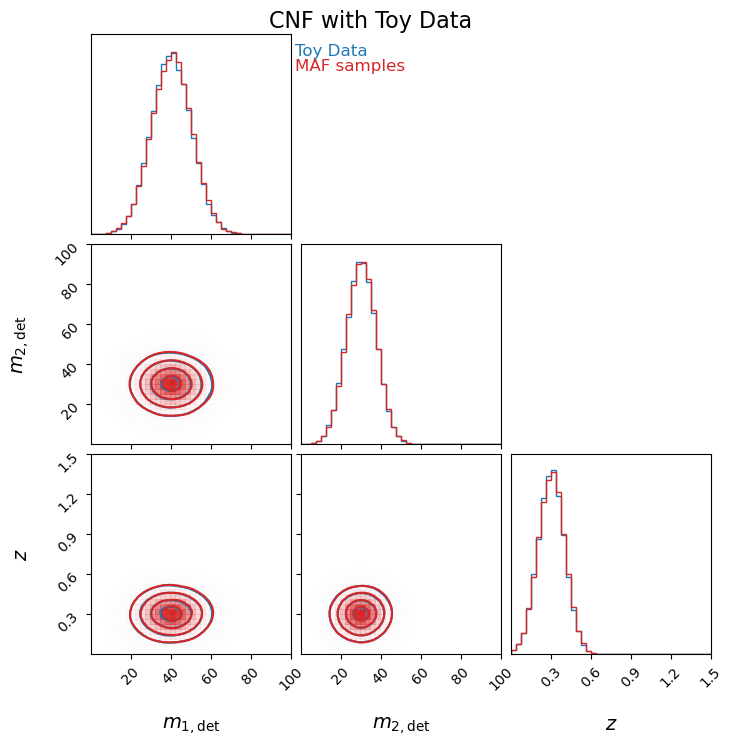

In [23]:
labels = [r"$m_{1,\rm det}$", r"$m_{2,\rm det}$", r"$z$"]
ranges = [(0, 100), (0, 100), (0, 1.5),]

data_samples = X_data.data_df[data_sel]

fig = corner.corner(
    data_samples,
    labels=labels,
    color="C0",
    bins=40,
    plot_datapoints=False,
    smooth=1.0,
    label_kwargs={"fontsize": 14},
    range = ranges,
)
x_rec = np.array(x_samples_orig_space)
corner.corner(
    x_rec,
    fig=fig,
    color="C3",
    bins=40,
    plot_datapoints=False,
    smooth=1.0,
    range = ranges,
)

fig.text(
    0.4, 0.92,
    "Toy Data",
    color="C0",
    fontsize=12,
)

fig.text(
    0.4, 0.9,
    "MAF samples",
    color="C3",
    fontsize=12,
)

plt.suptitle("CNF with Toy Data", fontsize=16)
plt.show()

### Quantitative Evaluation: Summary Statistics

Let's compare the descriptive statistics (mean, standard deviation, and correlations) of the original samples and the flow-generated samples. A good fit should show similar statistics between the two sets.

In [24]:
# Convert to pandas DataFrames for easy summary statistics
df_samples = data_samples
df_rec = pd.DataFrame(x_rec, columns=labels)

print("--- Original Samples Summary Statistics ---")
display(df_samples.describe())

print("\n--- Flow-Generated Samples Summary Statistics ---")
display(df_rec.describe())

print("\n--- Original Samples Correlation Matrix ---")
display(df_samples.corr())

print("\n--- Flow-Generated Samples Correlation Matrix ---")
display(df_rec.corr())

--- Original Samples Summary Statistics ---


,m1,m2,z
count,50000.000000,50000.000000,50000.000000
mean,40.030114,29.958537,0.300078
std,9.960222,7.472799,0.099699
min,0.014972,-1.867442,-0.096195
25%,33.281506,24.959429,0.233095
50%,40.003852,29.987239,0.300770
75%,46.758015,35.039702,0.367212
max,77.821941,62.062276,0.751677



--- Flow-Generated Samples Summary Statistics ---


,"$m_{1,\rm det}$","$m_{2,\rm det}$",$z$
count,50000.000000,50000.000000,50000.000000
mean,40.266312,30.080915,0.301677
std,10.042882,7.474187,0.100491
min,0.168718,-1.436314,-0.130503
25%,33.430916,25.017585,0.233398
50%,40.318939,30.106696,0.302817
75%,47.035706,35.132084,0.369442
max,85.214340,67.883667,0.741121



--- Original Samples Correlation Matrix ---


,m1,m2,z
m1,1.000000,-0.001938,0.000690
m2,-0.001938,1.000000,0.001226
z,0.000690,0.001226,1.000000



--- Flow-Generated Samples Correlation Matrix ---


,"$m_{1,\rm det}$","$m_{2,\rm det}$",$z$
"$m_{1,\rm det}$",1.000000,0.005426,0.002333
"$m_{2,\rm det}$",0.005426,1.000000,0.008301
$z$,0.002333,0.008301,1.000000


### Quantitative Evaluation: Kolmogorov-Smirnov (KS) Test

The Kolmogorov-Smirnov test is a non-parametric test that compares the empirical cumulative distribution functions (ECDFs) of two samples. We'll perform it for each 1D marginal distribution to check if the original and flow-generated samples come from the same underlying distribution. A small p-value (e.g., < 0.05) would suggest that the distributions are statistically significantly different.

In [25]:
from scipy import stats

print("--- Kolmogorov-Smirnov Test for 1D Marginals ---")
print("H0: The two samples are drawn from the same continuous distribution.")
print("If p-value is small (e.g., < 0.05), we reject H0, meaning distributions are likely different.")

for i, label in enumerate(labels):
    stat, p_value = stats.kstest(np.array(data_samples.to_numpy()[:, i]), x_rec[:, i])
    print(f"\nParameter: {label}")
    print(f"  KS Statistic: {stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  -> Distributions are statistically significantly different (reject H0)")
    else:
        print("  -> Distributions are not statistically significantly different (fail to reject H0)")

--- Kolmogorov-Smirnov Test for 1D Marginals ---
H0: The two samples are drawn from the same continuous distribution.
If p-value is small (e.g., < 0.05), we reject H0, meaning distributions are likely different.

Parameter: $m_{1,\rm det}$
  KS Statistic: 0.0135
  P-value: 0.0002
  -> Distributions are statistically significantly different (reject H0)

Parameter: $m_{2,\rm det}$
  KS Statistic: 0.0078
  P-value: 0.0950
  -> Distributions are not statistically significantly different (fail to reject H0)

Parameter: $z$
  KS Statistic: 0.0108
  P-value: 0.0061
  -> Distributions are statistically significantly different (reject H0)
